In [ ]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))  # Add parent folder

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from src.competitors import (
    export_benchmark_matrices,
    get_rezaeian_features,
    map_competitor_features,
)
from src.utils import load_metabric_data

In [ ]:
# Load and Filter for Luminal A
df = load_metabric_data()
df_LumA = df[df['pam50_+_claudin-low_subtype'] == 'LumA'].copy()
df_LumA['target_mortality'] = df_LumA['death_from_cancer'].apply(
    lambda x: 1 if str(x).strip().lower() == 'died of disease' else 0)

Fetching METABRIC dataset from Kaggle...


In [ ]:
df_LumA.shape

(679, 694)

In [ ]:
df_LumA.info()

<class 'pandas.DataFrame'>
Index: 679 entries, 1 to 1899
Columns: 694 entries, patient_id to target_mortality
dtypes: float64(498), int64(6), str(190)
memory usage: 3.6 MB


In [ ]:
'integrative_cluster' in df_LumA.columns

True

In [ ]:
df_LumA['integrative_cluster'].value_counts()

integrative_cluster
3       189
8       185
7       117
4ER+     87
2        25
9        24
6        22
5        17
1        11
10        1
4ER-      1
Name: count, dtype: int64

In [ ]:
'abc' in 'abcd'

True

In [ ]:
# Map Competitor Features
rezaeian_list = get_rezaeian_features()
features = map_competitor_features(df_LumA.columns, rezaeian_list)

Mapped 53 features (mRNA + Mutations) from the 39 genes in the signature.


In [ ]:
rezaeian_list

['bbc3',
 'cdkn2a',
 'wfdc2',
 'hes2',
 'hsd3b7',
 'rps6kb1',
 'e2f6',
 'srd5a3',
 'mmp25',
 'mmp21',
 'dnah5',
 'sf3b1',
 'chek2',
 'sik1',
 'bmpr2',
 'hey1',
 'mmp27',
 'stmn2',
 'mapk3',
 'pdgfa',
 'taf4b',
 'ctbp1',
 'igf1r',
 'notch2',
 'arid2',
 'arid1a',
 'spry2',
 'cdkn2c',
 'gata3',
 'spen',
 'ccnd2',
 'smad2',
 'map3k5',
 'prkg1',
 'terc',
 'hes6',
 'nrarp',
 'agtr2',
 'pde4dip']

In [ ]:
X = df_LumA[features]
y = df_LumA['target_mortality']

In [ ]:
X.info()

<class 'pandas.DataFrame'>
Index: 679 entries, 1 to 1899
Data columns (total 53 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   chek2        679 non-null    float64
 1   ccnd2        679 non-null    float64
 2   cdkn2a       679 non-null    float64
 3   e2f6         679 non-null    float64
 4   ctbp1        679 non-null    float64
 5   notch2       679 non-null    float64
 6   nrarp        679 non-null    float64
 7   spen         679 non-null    float64
 8   hes2         679 non-null    float64
 9   hey1         679 non-null    float64
 10  bmpr2        679 non-null    float64
 11  igf1r        679 non-null    float64
 12  map3k5       679 non-null    float64
 13  mapk3        679 non-null    float64
 14  mmp21        679 non-null    float64
 15  mmp25        679 non-null    float64
 16  mmp27        679 non-null    float64
 17  pdgfa        679 non-null    float64
 18  rps6kb1      679 non-null    float64
 19  smad2        679 non-nu

In [ ]:
X['smad2_mut'].value_counts()

smad2_mut
0        676
S2L        1
L261F      1
D59H       1
Name: count, dtype: int64

In [ ]:
# In METABRIC, mutation columns contain '0' for no mutation
# and strings like 'X308_splice' for actual mutations.
# This loop converts them to 0s and 1s.
for col in X.columns:
    if col.endswith('_mut'):
        # If it's '0', keep as 0. If it's anything else (string), make it 1.
        X[col] = (X[col] != '0').astype(int)
    else:
        # Ensure mRNA columns are numeric
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

In [ ]:
X['smad2_mut'].value_counts()

smad2_mut
0    676
1      3
Name: count, dtype: int64

In [ ]:
# Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Replicate the Grid Search from original benchmark
models_to_test = {
    'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=42), {
        'C': [0.1, 1, 10], 'class_weight': ['balanced', None]
    }),
    'SVM': (SVC(probability=True, random_state=42), {
        'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'class_weight': ['balanced', None]
    }),
    'RandomForest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 10], 'class_weight': ['balanced', None]
    })
}

best_bench_model = None
best_score = 0
winner_name = ""

for name, (model, params) in models_to_test.items():
    grid = GridSearchCV(model, params, cv=5, scoring='roc_auc')
    grid.fit(X_train_scaled, y_train)
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_bench_model = grid.best_estimator_
        winner_name = name

In [ ]:
best_bench_model

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


[SVM_Untuned] Threshold: 0.500 | AP: 0.345


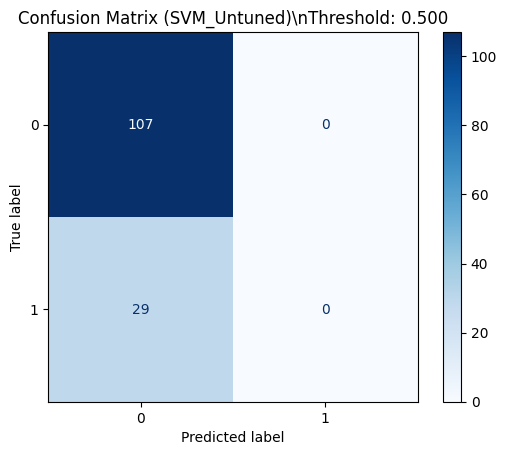

In [ ]:
# Demonstrate WITHOUT tuning
export_benchmark_matrices(best_bench_model, X_test_scaled, y_test,
                          threshold=0.5, suffix=f"{winner_name}_Untuned")

[SVM_Tuned] Threshold: 0.225 | AP: 0.345


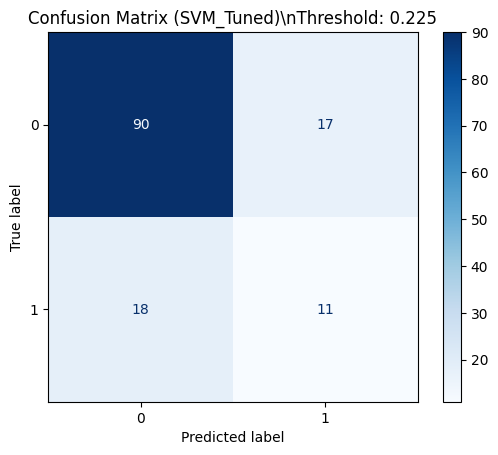

In [ ]:
# Demonstrate WITH tuning (PR-Optimal)
export_benchmark_matrices(best_bench_model, X_test_scaled, y_test,
                          threshold=None, suffix=f"{winner_name}_Tuned")

In [ ]:
# print("WITH THRESHOLD TUNING (Precision-Recall Optimal)")
# # The function automatically calculates the best PR threshold if we don't force one
# export_benchmark_matrices(
#     competitor_model,
#     X_test_scaled,
#     y_test,
#     suffix="Tuned_PR_Curve",
#     save_file=False
# )

WITH THRESHOLD TUNING (Precision-Recall Optimal)


NameError: name 'competitor_model' is not defined